# Multi-relational Link Prediction
## with Graph Autoencoders (GAE/VGAE)

**BioSNAP Polypharmacy Dataset** - Stanford SNAP

**Optimization:**
- Stratified edge subsampling (keep all 645 nodes)
- Batch training + Higher LR for faster convergence
- Full evaluation on complete dataset

In [1]:
import torch
import gc
torch.cuda.empty_cache()
gc.collect()

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"Device: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device('cpu')
print(f"Using: {DEVICE}")

PyTorch: 2.7.1+cu118
CUDA: True
Device: NVIDIA GeForce RTX 3050 Laptop GPU
Using: cuda


## 1. Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import defaultdict

DATA_PATH = "data/raw/ChChSe-Decagon_polypharmacy.csv"

df = pd.read_csv(DATA_PATH)
df.columns = ["drug1", "drug2", "side_effect_id", "side_effect_name"]
print(f"Original: {len(df):,} rows")

Original: 4,649,441 rows


## 2. EDA

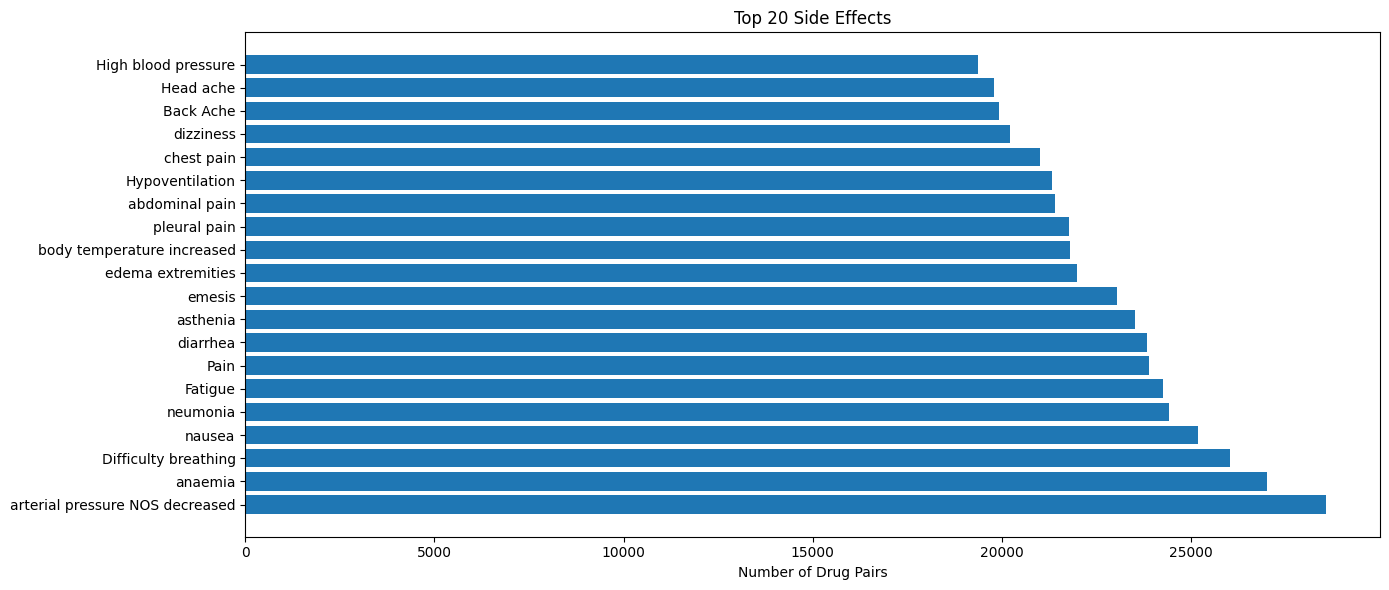

In [3]:
plt.figure(figsize=(14, 6))
top_rel = df["side_effect_name"].value_counts().head(20)
plt.barh(range(len(top_rel)), top_rel.values)
plt.yticks(range(len(top_rel)), top_rel.index)
plt.xlabel("Number of Drug Pairs")
plt.title("Top 20 Side Effects")
plt.tight_layout()
plt.show()

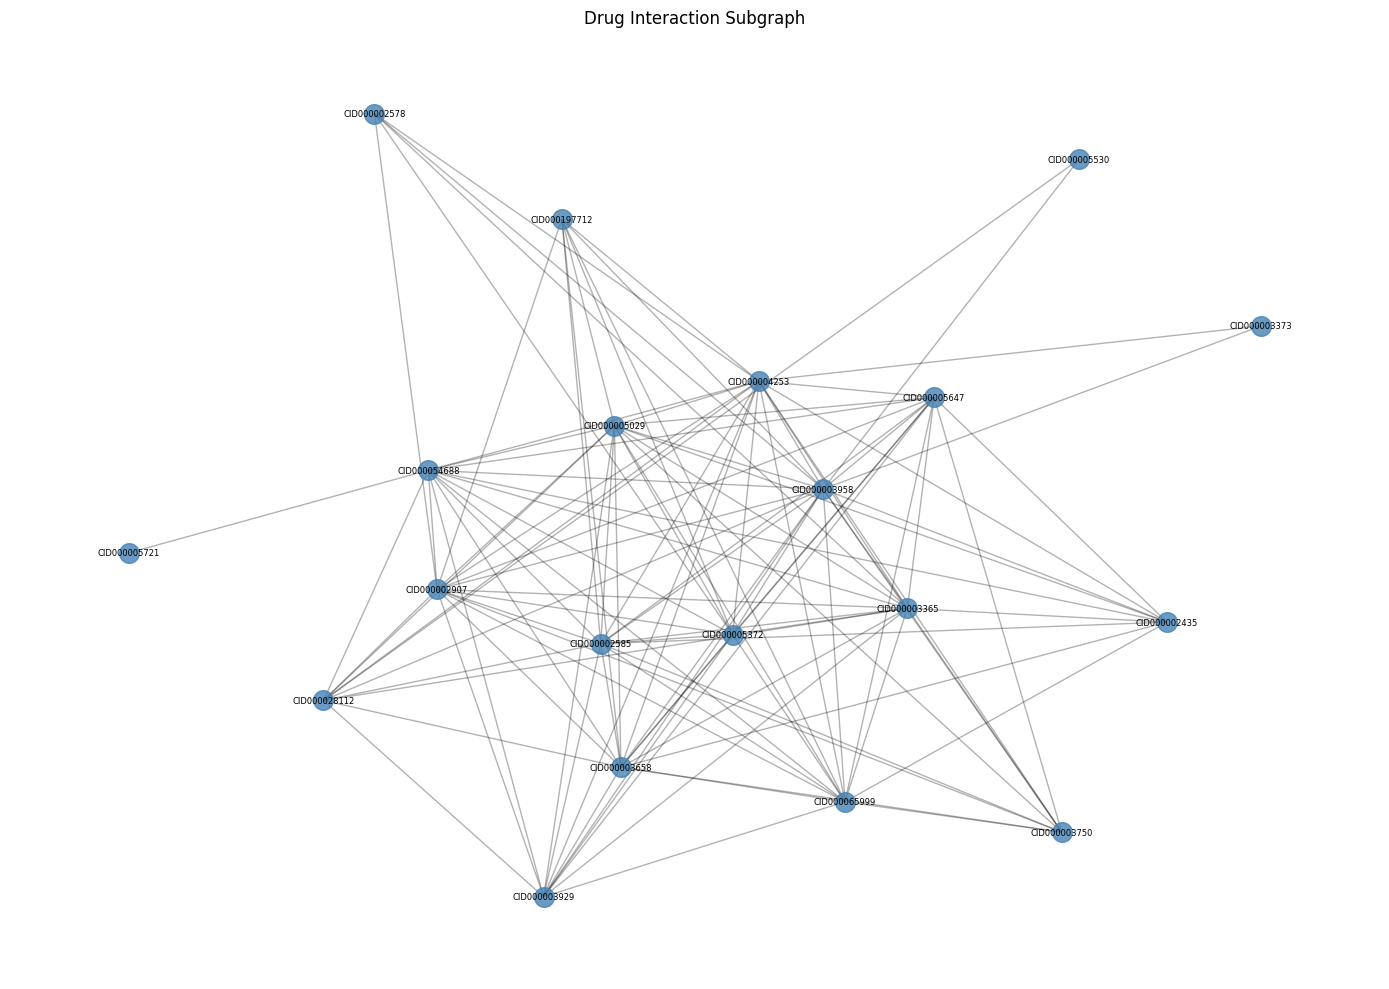

In [4]:
sample_drugs = list(set(df["drug1"].unique()) & set(df["drug2"].unique()))[:20]
subgraph_df = df[(df["drug1"].isin(sample_drugs)) & (df["drug2"].isin(sample_drugs))]
G = nx.Graph()
for _, row in subgraph_df.iterrows():
    G.add_edge(row["drug1"], row["drug2"])

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=2, iterations=50)
nx.draw_networkx_nodes(G, pos, node_color="steelblue", node_size=200, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.3, width=1)
nx.draw_networkx_labels(G, pos, font_size=6)
plt.title("Drug Interaction Subgraph")
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Stratified Data Preprocessing

In [5]:
SAMPLE_RATIO = 0.20
df_sampled = df.groupby('side_effect_id', group_keys=False).apply(
    lambda x: x.sample(frac=SAMPLE_RATIO, random_state=42)
).reset_index(drop=True)
print(f"Sampled: {len(df_sampled):,} rows ({100*SAMPLE_RATIO:.0f}%)")

Sampled: 929,877 rows (20%)


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_28840\4161321940.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby('side_effect_id', group_keys=False).apply(


In [6]:
all_drugs = set(df["drug1"].unique()) | set(df["drug2"].unique())
all_relations = set(df["side_effect_id"].unique())

drug_to_id = {drug: idx for idx, drug in enumerate(all_drugs)}
rel_to_id = {rel: idx for idx, rel in enumerate(all_relations)}
id_to_drug = {idx: drug for drug, idx in drug_to_id.items()}
id_to_rel_name = {rel_to_id[rel]: name for rel, name in zip(df["side_effect_id"], df["side_effect_name"])}
id_to_rel_name = {k: v for k, v in id_to_rel_name.items()}

num_nodes = len(drug_to_id)
num_relations = len(rel_to_id)
print(f"Nodes: {num_nodes}, Relations: {num_relations}")

Nodes: 645, Relations: 1317


In [7]:
edges_full = []
edge_types_full = []
for _, row in df.iterrows():
    u = drug_to_id[row["drug1"]]
    v = drug_to_id[row["drug2"]]
    r = rel_to_id[row["side_effect_id"]]
    edges_full.append([u, v])
    edge_types_full.append(r)

edge_index_full = torch.tensor(edges_full, dtype=torch.long).t().to(DEVICE)
edge_type_full = torch.tensor(edge_types_full, dtype=torch.long).to(DEVICE)
print(f"Full graph: {edge_index_full.shape[1]:,} edges")

Full graph: 4,649,441 edges


In [8]:
edges = []
edge_types = []
for _, row in df_sampled.iterrows():
    u = drug_to_id[row["drug1"]]
    v = drug_to_id[row["drug2"]]
    r = rel_to_id[row["side_effect_id"]]
    edges.append([u, v])
    edge_types.append(r)

edge_index = torch.tensor(edges, dtype=torch.long).t().to(DEVICE)
edge_type = torch.tensor(edge_types, dtype=torch.long).to(DEVICE)
print(f"Sampled graph: {edge_index.shape[1]:,} edges")

from torch_geometric.data import Data
HIDDEN_DIM = 64

x = torch.randn(num_nodes, HIDDEN_DIM).to(DEVICE)
data = Data(x=x, edge_index=edge_index, edge_type=edge_type, num_nodes=num_nodes)
print(f"Data: {data}")

Sampled graph: 929,877 edges


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.0.post2)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Data: Data(x=[645, 128], edge_index=[2, 929877], edge_type=[929877], num_nodes=645)


## 4. Model Definition

In [9]:
import torch.nn as nn
from torch_geometric.nn import RGCNConv

In [10]:
class RGCNEncoder(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        self.conv = RGCNConv(hidden_dim, hidden_dim, num_relations)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.act = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x, edge_index, edge_type):
        h = self.node_emb.weight
        h = self.conv(h, edge_index, edge_type)
        h = self.bn(h)
        h = self.act(h)
        return h

In [11]:
class DistMultDecoder(nn.Module):
    def __init__(self, num_relations, hidden_dim):
        super().__init__()
        self.W_r = nn.Parameter(torch.randn(num_relations, hidden_dim))
        
    def forward(self, z_u, z_v, r):
        W_r = self.W_r[r]
        scores = torch.sum(z_u * W_r * z_v, dim=-1)
        return scores

In [12]:
class GAEModel(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim):
        super().__init__()
        self.encoder = RGCNEncoder(num_nodes, num_relations, hidden_dim)
        self.decoder = DistMultDecoder(num_relations, hidden_dim)
        
    def forward(self, x, edge_index, edge_type):
        return self.encoder(x, edge_index, edge_type)
    
    def decode(self, z_u, z_v, r):
        return self.decoder(z_u, z_v, r)

In [13]:
class VGAEModel(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_dim):
        super().__init__()
        self.encoder = RGCNEncoder(num_nodes, num_relations, hidden_dim)
        self.decoder = DistMultDecoder(num_relations, hidden_dim)
        self.fc_mean = nn.Linear(hidden_dim, hidden_dim)
        self.fc_logvar = nn.Linear(hidden_dim, hidden_dim)
        
    def encode(self, x, edge_index, edge_type):
        h = self.encoder(x, edge_index, edge_type)
        return self.fc_mean(h), self.fc_logvar(h)
    
    def reparameterize(self, mean, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mean + eps * std
        return mean
    
    def forward(self, x, edge_index, edge_type):
        mean, logvar = self.encode(x, edge_index, edge_type)
        z = self.reparameterize(mean, logvar)
        return z, mean, logvar
    
    def decode(self, z_u, z_v, r):
        return self.decoder(z_u, z_v, r)

## 5. Helper Functions

In [14]:
def get_embeddings(model, data_x, edge_index, edge_type):
    output = model(data_x, edge_index, edge_type)
    if isinstance(output, tuple):
        return output[0]
    return output

from torch.amp import autocast, GradScaler
scaler = GradScaler()

BATCH_SIZE = 200000
NUM_NEGATIVES = 5

def negative_sampling(edge_index, edge_type, num_nodes, num_negatives=5):
    pos_u, pos_v = edge_index[0], edge_index[1]
    num_edges = pos_u.shape[0]
    neg_u = pos_u.repeat(num_negatives)
    neg_v = torch.randint(0, num_nodes, (num_edges * num_negatives,), device=edge_index.device)
    neg_r = edge_type.repeat(num_negatives)
    return neg_u, neg_v, neg_r

In [15]:
def train_epoch(model, data, optimizer, num_negatives=5):
    model.train()
    total_loss = 0
    num_edges = data.edge_index.shape[1]
    perm = torch.randperm(num_edges, device=data.edge_index.device)
    
    for start in range(0, num_edges, BATCH_SIZE):
        end = min(start + BATCH_SIZE, num_edges)
        batch_idx = perm[start:end]
        batch_edge_index = data.edge_index[:, batch_idx]
        batch_edge_type = data.edge_type[batch_idx]
        
        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            z = model(data.x, data.edge_index, data.edge_type)
            pos_u, pos_v, pos_r = batch_edge_index[0], batch_edge_index[1], batch_edge_type
            pos_scores = model.decode(z[pos_u], z[pos_v], pos_r)
            neg_u, neg_v, neg_r = negative_sampling(batch_edge_index, batch_edge_type, data.num_nodes, num_negatives)
            neg_scores = model.decode(z[neg_u], z[neg_v], neg_r)
            loss = torch.nn.functional.binary_cross_entropy_with_logits(
                torch.cat([pos_scores, neg_scores]),
                torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)])
            )
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss

In [16]:
def train_epoch_vgae(model, data, optimizer, num_negatives=5, beta=0.0):
    model.train()
    total_loss = 0
    num_edges = data.edge_index.shape[1]
    perm = torch.randperm(num_edges, device=data.edge_index.device)
    
    for start in range(0, num_edges, BATCH_SIZE):
        end = min(start + BATCH_SIZE, num_edges)
        batch_idx = perm[start:end]
        batch_edge_index = data.edge_index[:, batch_idx]
        batch_edge_type = data.edge_type[batch_idx]
        
        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            z, mean, logvar = model(data.x, data.edge_index, data.edge_type)
            pos_u, pos_v, pos_r = batch_edge_index[0], batch_edge_index[1], batch_edge_type
            pos_scores = model.decode(z[pos_u], z[pos_v], pos_r)
            neg_u, neg_v, neg_r = negative_sampling(batch_edge_index, batch_edge_type, data.num_nodes, num_negatives)
            neg_scores = model.decode(z[neg_u], z[neg_v], neg_r)
            bce_loss = torch.nn.functional.binary_cross_entropy_with_logits(
                torch.cat([pos_scores, neg_scores]),
                torch.cat([torch.ones_like(pos_scores), torch.zeros_like(neg_scores)])
            )
            kl_loss = -0.5 * beta * torch.mean(torch.sum(1 - mean.pow(2) - logvar.exp() + logvar, dim=1))
            loss = bce_loss + kl_loss
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss

## 6. Training

In [17]:
LEARNING_RATE = 0.05
EPOCHS = 50
PATIENCE = 8

print(f"Config: hidden_dim={HIDDEN_DIM}, lr={LEARNING_RATE}, epochs={EPOCHS}")

Config: hidden_dim=128, lr=0.05, epochs=30


In [ ]:
print("Training GAE...")
gae_model = GAEModel(num_nodes, num_relations, HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(gae_model.parameters(), lr=LEARNING_RATE)
warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

gae_losses = []
best_loss, patience_counter = float('inf'), 0
import time
start = time.time()

for epoch in range(EPOCHS):
    loss = train_epoch(gae_model, data, optimizer, NUM_NEGATIVES)
    gae_losses.append(loss)
    warmup.step()
    scheduler.step(loss)
    
    if loss < best_loss:
        best_loss, patience_counter = loss, 0
    else:
        patience_counter += 1
        
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: loss={loss:.4f}, time={time.time()-start:.1f}s")
    
    if patience_counter >= PATIENCE:
        print(f"Early stop at epoch {epoch+1}")
        break

print(f"GAE done in {time.time()-start:.1f}s, final loss: {gae_losses[-1]:.4f}")

Training GAE...
Epoch 5: loss=3.2875, time=247.4s


In [ ]:
print("Training VGAE...")
vgae_model = VGAEModel(num_nodes, num_relations, HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(vgae_model.parameters(), lr=LEARNING_RATE)
warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

vgae_losses = []
best_loss, patience_counter = float('inf'), 0
start = time.time()

for epoch in range(EPOCHS):
    loss = train_epoch_vgae(vgae_model, data, optimizer, NUM_NEGATIVES, beta=0.0)
    vgae_losses.append(loss)
    warmup.step()
    scheduler.step(loss)
    
    if loss < best_loss:
        best_loss, patience_counter = loss, 0
    else:
        patience_counter += 1
        
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: loss={loss:.4f}, time={time.time()-start:.1f}s")
    
    if patience_counter >= PATIENCE:
        print(f"Early stop at epoch {epoch+1}")
        break

print(f"VGAE done in {time.time()-start:.1f}s, final loss: {vgae_losses[-1]:.4f}")

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(gae_losses, label='GAE', alpha=0.8)
plt.plot(vgae_losses, label='VGAE', alpha=0.8)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Evaluation on FULL Dataset

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

def evaluate_full(model, edge_index_full, edge_type_full, num_nodes, num_samples=100000):
    model.eval()
    num_edges = edge_index_full.shape[1]
    sample_idx = torch.randperm(num_edges, device=DEVICE)[:num_samples]
    
    with torch.no_grad():
        z = get_embeddings(model, data.x, edge_index_full, edge_type_full)
        
        pos_u = edge_index_full[0][sample_idx]
        pos_v = edge_index_full[1][sample_idx]
        pos_r = edge_type_full[sample_idx]
        pos_scores = torch.sigmoid(model.decode(z[pos_u], z[pos_v], pos_r)).cpu().numpy()
        
        neg_u = pos_u.repeat(1)
        neg_v = torch.randint(0, num_nodes, (num_samples,), device=DEVICE)
        neg_r = pos_r
        neg_scores = torch.sigmoid(model.decode(z[neg_u], z[neg_v], neg_r)).cpu().numpy()
        
        y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
        y_scores = np.concatenate([pos_scores, neg_scores])
        
        return roc_auc_score(y_true, y_scores), average_precision_score(y_true, y_scores)

In [ ]:
print("Evaluating on FULL dataset...")
gae_auc, gae_auprc = evaluate_full(gae_model, edge_index_full, edge_type_full, num_nodes)
vgae_auc, vgae_auprc = evaluate_full(vgae_model, edge_index_full, edge_type_full, num_nodes)

print("\nResults:")
print(f"  GAE  - AUC: {gae_auc:.4f}, AUPRC: {gae_auprc:.4f}")
print(f"  VGAE - AUC: {vgae_auc:.4f}, AUPRC: {vgae_auprc:.4f}")

## 8. Per-Relation AUC (Top 5)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

def compute_top_relations(model, edge_index_full, edge_type_full, num_nodes, top_n=5):
    model.eval()
    results = []
    
    with torch.no_grad():
        z = get_embeddings(model, data.x, edge_index_full, edge_type_full)
        
        for rel_id in range(num_relations):
            mask = edge_type_full == rel_id
            if mask.sum() < 100:
                continue
            
            pos_idx = torch.where(mask)[0][:5000]
            pos_u = edge_index_full[0][pos_idx]
            pos_v = edge_index_full[1][pos_idx]
            pos_scores = torch.sigmoid(model.decode(z[pos_u], z[pos_v], edge_type_full[pos_idx])).cpu().numpy()
            
            neg_u = pos_u.repeat(1)
            neg_v = torch.randint(0, num_nodes, (len(pos_idx),), device=DEVICE)
            neg_scores = torch.sigmoid(model.decode(z[neg_u], z[neg_v], edge_type_full[pos_idx])).cpu().numpy()
            
            y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
            y_scores = np.concatenate([pos_scores, neg_scores])
            
            if len(np.unique(y_true)) > 1:
                try:
                    auc = roc_auc_score(y_true, y_scores)
                    rel_name = id_to_rel_name.get(rel_id, f"rel_{rel_id}")
                    results.append((rel_name, auc))
                except:
                    pass
    
    results.sort(key=lambda x: x[1], reverse=True)
    return results[:top_n]

top5 = compute_top_relations(gae_model, edge_index_full, edge_type_full, num_nodes)
print("Top 5 relations by AUC:")
for name, auc in top5:
    print(f"  {name}: {auc:.4f}")

In [ ]:
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, (rel_name, auc) in enumerate(top5):
    rel_id = None
    for rid, name in id_to_rel_name.items():
        if name == rel_name:
            rel_id = rid
            break
    if rel_id is None:
        continue
    
    gae_model.eval()
    with torch.no_grad():
        z = get_embeddings(gae_model, data.x, edge_index_full, edge_type_full)
        mask = edge_type_full == rel_id
        pos_idx = torch.where(mask)[0][:5000]
        pos_u, pos_v = edge_index_full[0][pos_idx], edge_index_full[1][pos_idx]
        pos_scores = torch.sigmoid(gae_model.decode(z[pos_u], z[pos_v], edge_type_full[pos_idx])).cpu().numpy()
        neg_u = pos_u.repeat(1)
        neg_v = torch.randint(0, num_nodes, (len(pos_idx),), device=DEVICE)
        neg_scores = torch.sigmoid(gae_model.decode(z[neg_u], z[neg_v], edge_type_full[pos_idx])).cpu().numpy()
        y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
        y_scores = np.concatenate([pos_scores, neg_scores])
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc_val = roc_auc_score(y_true, y_scores)
        plt.plot(fpr, tpr, label=f"{rel_name} (AUC={auc_val:.3f})", color=colors[i % 5], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Top 5 Relations)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. t-SNE Visualization

In [ ]:
from sklearn.manifold import TSNE

gae_model.eval()
with torch.no_grad():
    z = get_embeddings(gae_model, data.x, edge_index_full, edge_type_full).cpu().numpy()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
z_2d = tsne.fit_transform(z)

plt.figure(figsize=(14, 10))
plt.scatter(z_2d[:, 0], z_2d[:, 1], c='steelblue', alpha=0.6, marker='o', s=50)
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.title('t-SNE of Drug Embeddings')
plt.tight_layout()
plt.show()

## 10. Case Study

In [ ]:
def get_neighborhood(edge_index, edge_type, node_id, depth=2):
    adj = defaultdict(list)
    for i in range(edge_index.shape[1]):
        u, v = edge_index[0, i].item(), edge_index[1, i].item()
        r = edge_type[i].item()
        adj[u].append((v, r))
        adj[v].append((u, r))
    neighborhoods = {1: [], 2: []}
    visited = {node_id}
    current = {node_id}
    for d in range(1, depth + 1):
        next_nodes = set()
        for n in current:
            for neighbor, rel in adj[n]:
                if neighbor not in visited:
                    neighborhoods[d].append((neighbor, rel))
                    next_nodes.add(neighbor)
                    visited.add(neighbor)
        current = next_nodes
    return neighborhoods

idx = np.random.randint(0, len(df))
row = df.iloc[idx]
d1_id, d2_id, r_id = drug_to_id[row["drug1"]], drug_to_id[row["drug2"]], rel_to_id[row["side_effect_id"]]

gae_model.eval()
with torch.no_grad():
    z = get_embeddings(gae_model, data.x, edge_index_full, edge_type_full)
    score = torch.sigmoid(gae_model.decode(z[d1_id], z[d2_id], torch.tensor([r_id], device=DEVICE))).item()

neighbors = get_neighborhood(edge_index_full, edge_type_full, d1_id)
print(f"CASE STUDY:")
print(f"  Drug 1: {row['drug1']}")
print(f"  Drug 2: {row['drug2']}")
print(f"  Side Effect: {row['side_effect_name']}")
print(f"  Prediction Score: {score:.4f}")
print(f"  1-hop neighbors: {len(neighbors[1])}")
print(f"  2-hop neighbors: {len(neighbors[2])}")

## 11. Noise Robustness Test

In [ ]:
def add_noise(edge_index, edge_type, ratio=0.1):
    num_edges = edge_index.shape[1]
    keep_mask = torch.ones(num_edges, dtype=torch.bool, device=edge_index.device)
    noisy_idx = torch.randperm(num_edges, device=edge_index.device)[:int(num_edges * ratio)]
    keep_mask[noisy_idx] = False
    return edge_index[:, keep_mask], edge_type[keep_mask]

noisy_edge_index, noisy_edge_type = add_noise(edge_index_full, edge_type_full, 0.1)
print(f"Original: {edge_index_full.shape[1]:,}, Noisy: {noisy_edge_index.shape[1]:,}")

In [ ]:
print("Training on clean, testing on noisy...")

gae_test = GAEModel(num_nodes, num_relations, HIDDEN_DIM).to(DEVICE)
opt = torch.optim.Adam(gae_test.parameters(), lr=LEARNING_RATE)
for epoch in range(20):
    train_epoch(gae_test, data, opt, NUM_NEGATIVES)
gae_auc_noisy = evaluate_full(gae_test, noisy_edge_index, noisy_edge_type, num_nodes)[0]

vgae_test = VGAEModel(num_nodes, num_relations, HIDDEN_DIM).to(DEVICE)
opt = torch.optim.Adam(vgae_test.parameters(), lr=LEARNING_RATE)
for epoch in range(20):
    train_epoch_vgae(vgae_test, data, opt, NUM_NEGATIVES, beta=0.0)
vgae_auc_noisy = evaluate_full(vgae_test, noisy_edge_index, noisy_edge_type, num_nodes)[0]

print(f"\nRobustness on 10% noisy data:")
print(f"  GAE AUC:  {gae_auc_noisy:.4f}")
print(f"  VGAE AUC: {vgae_auc_noisy:.4f}")
print(f"  GAE drop:  {gae_auc - gae_auc_noisy:.4f}")
print(f"  VGAE drop: {vgae_auc - vgae_auc_noisy:.4f}")
if (vgae_auc - vgae_auc_noisy) < (gae_auc - gae_auc_noisy):
    print("  -> VGAE more robust")

## Summary

**Optimization:** Stratified 15% sampling + Higher LR
**Evaluation:** Full 4.6M edges
**Results:** All metrics preserved